# Описание
Данный ноутбук нужен для демонстрации работы, если хотите воспроизвести результаты, то придется склонировать репозиторий и скомпилировать код
```bash
cmake -S . -B build -DCMAKE_BUILD_TYPE=Release
cmake --build build
```

In [1]:
import ctypes
import csv
import math
import os
import random
import urllib.request
from pathlib import Path

# Хотелось бы только стандартную библиотеку использовать, но красиво будет для визуализации
import matplotlib.pyplot as plt

<div class="alert alert-warning">
<strong>⚠️ Осторожно!</strong> Если у вас мак, ничего менять не надо, если же винда/линукс, то скомпилируйте проект и найдите там файл с расширением .so или .dll и поменяйте в lib_path ссылку
</div>

In [2]:
LIB_PATH = Path("./build/libtinygradc.dylib")

# Python-обертка для работы с Си

In [3]:
class TinyGradC:
    def __init__(self, lib_path, arena_bytes=8 * 1024 * 1024):
        self.lib = ctypes.CDLL(lib_path)

        c_void_p = ctypes.c_void_p
        c_int = ctypes.c_int
        c_float = ctypes.c_float
        c_bool = ctypes.c_bool
        c_size_t = ctypes.c_size_t
        float_p = ctypes.POINTER(c_float)

        self.c_void_p = c_void_p
        self.c_int = c_int
        self.c_float = c_float
        self.c_bool = c_bool
        self.c_size_t = c_size_t
        self.float_p = float_p

        # arena
        self.lib.tg_arena_create.argtypes = [c_size_t]
        self.lib.tg_arena_create.restype = c_void_p

        self.lib.tg_arena_destroy.argtypes = [c_void_p]
        self.lib.tg_arena_destroy.restype = None

        self.lib.tg_arena_reset.argtypes = [c_void_p]
        self.lib.tg_arena_reset.restype = None

        # tensor / params
        self.lib.tg_param_create.argtypes = [c_int, c_int, c_bool]
        self.lib.tg_param_create.restype = c_void_p

        self.lib.tg_param_free.argtypes = [c_void_p]
        self.lib.tg_param_free.restype = None

        self.lib.tg_tensor_from_buffer.argtypes = [c_void_p, float_p, c_int, c_int, c_bool]
        self.lib.tg_tensor_from_buffer.restype = c_void_p

        self.lib.tg_tensor_data.argtypes = [c_void_p]
        self.lib.tg_tensor_data.restype = float_p

        self.lib.tg_numel.argtypes = [c_void_p]
        self.lib.tg_numel.restype = c_size_t

        self.lib.tg_zero_grad.argtypes = [c_void_p]
        self.lib.tg_zero_grad.restype = None

        # ops
        self.lib.tg_matmul.argtypes = [c_void_p, c_void_p, c_void_p]
        self.lib.tg_matmul.restype = c_void_p

        self.lib.tg_add.argtypes = [c_void_p, c_void_p, c_void_p]
        self.lib.tg_add.restype = c_void_p

        self.lib.tg_relu.argtypes = [c_void_p, c_void_p]
        self.lib.tg_relu.restype = c_void_p

        # losses
        self.lib.tg_softmax_cross_entropy.argtypes = [c_void_p, c_void_p, c_void_p]
        self.lib.tg_softmax_cross_entropy.restype = c_void_p

        # autograd
        self.lib.tg_backward.argtypes = [c_void_p]
        self.lib.tg_backward.restype = c_int

        # optimizer
        self.lib.tg_adam_step.argtypes = [
            ctypes.POINTER(c_void_p),  # params
            c_int,                     # n
            c_float,                   # lr
            c_float,                   # beta1
            c_float,                   # beta2
            c_float,                   # eps
            c_int                      # t
        ]
        self.lib.tg_adam_step.restype = None

        self.arena = self.lib.tg_arena_create(arena_bytes)
        if not self.arena:
            raise RuntimeError("tg_arena_create failed")

    def close(self):
        if self.arena:
            self.lib.tg_arena_destroy(self.arena)
            self.arena = None

    def reset(self):
        self.lib.tg_arena_reset(self.arena)

    def param(self, rows, cols, requires_grad=True):
        t = self.lib.tg_param_create(rows, cols, requires_grad)
        if not t:
            raise RuntimeError(f"tg_param_create failed for [{rows} x {cols}]")
        return t

    def free_param(self, t):
        if t:
            self.lib.tg_param_free(t)

    def numel(self, t):
        return int(self.lib.tg_numel(t))

    def data_ptr(self, t):
        ptr = self.lib.tg_tensor_data(t)
        if not ptr:
            raise RuntimeError("tg_tensor_data returned NULL")
        return ptr

    def scalar(self, t):
        ptr = self.data_ptr(t)
        return float(ptr[0])

    def zero_grad(self, t):
        self.lib.tg_zero_grad(t)

    def zero_grads(self, params):
        for p in params:
            self.zero_grad(p)

    def adam_step(self, params, lr, beta1, beta2, eps, t):
        arr = (self.c_void_p * len(params))(*params)
        self.lib.tg_adam_step(arr, len(params), lr, beta1, beta2, eps, t)

    def tensor_from_2d_list(self, data_2d, requires_grad=False):
        rows = len(data_2d)
        if rows == 0:
            raise ValueError("empty data")
        cols = len(data_2d[0])

        flat = []
        for row in data_2d:
            if len(row) != cols:
                raise ValueError("ragged 2D list")
            flat.extend(float(x) for x in row)

        buf = (self.c_float * (rows * cols))(*flat)
        t = self.lib.tg_tensor_from_buffer(self.arena, buf, rows, cols, requires_grad)
        if not t:
            raise RuntimeError("tg_tensor_from_buffer failed")
        return t, buf  # buf нужно вернуть, чтобы память жила

    def copy_list_into_param(self, t, values):
        n = self.numel(t)
        if len(values) != n:
            raise ValueError(f"size mismatch: tensor has {n}, values have {len(values)}")
        ptr = self.data_ptr(t)
        for i, v in enumerate(values):
            ptr[i] = float(v)

    def read_tensor_as_2d_list(self, t, rows, cols):
        ptr = self.data_ptr(t)
        out = []
        k = 0
        for r in range(rows):
            row = []
            for c in range(cols):
                row.append(float(ptr[k]))
                k += 1
            out.append(row)
        return out

    # ops
    def matmul(self, a, b):
        out = self.lib.tg_matmul(self.arena, a, b)
        if not out:
            raise RuntimeError("tg_matmul failed")
        return out

    def add(self, a, b):
        out = self.lib.tg_add(self.arena, a, b)
        if not out:
            raise RuntimeError("tg_add failed")
        return out

    def relu(self, x):
        out = self.lib.tg_relu(self.arena, x)
        if not out:
            raise RuntimeError("tg_relu failed")
        return out

    def softmax_ce(self, logits, target_onehot):
        out = self.lib.tg_softmax_cross_entropy(self.arena, logits, target_onehot)
        if not out:
            raise RuntimeError("tg_softmax_cross_entropy failed")
        return out

    def backward(self, loss):
        st = self.lib.tg_backward(loss)
        if st != 0:
            raise RuntimeError(f"tg_backward failed with status={st}")


# Импорт датасета

In [4]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

TRAIN_FILE = DATA_DIR / "optdigits.tra"
TEST_FILE = DATA_DIR / "optdigits.tes"

TRAIN_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra"
TEST_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes"

def download_if_missing(path, url):
    if path.exists():
        print(f"Found: {path}")
        return
    print(f"Downloading {url} -> {path}")
    urllib.request.urlretrieve(url, path)

download_if_missing(TRAIN_FILE, TRAIN_URL)
download_if_missing(TEST_FILE, TEST_URL)

Found: data/optdigits.tra
Found: data/optdigits.tes


In [5]:
def load_optdigits_csv(path):
    X = []
    y = []

    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            vals = [int(v) for v in row]
            features = vals[:-1]
            label = vals[-1]

            features = [v / 16.0 for v in features]  # Просто нормализация, 16 не с потолка

            X.append(features)
            y.append(label)

    return X, y

X_train, y_train = load_optdigits_csv(TRAIN_FILE)
X_test, y_test = load_optdigits_csv(TEST_FILE)

print("Train size:", len(X_train))
print("Test size :", len(X_test))
print("Feature dim:", len(X_train[0]))

Train size: 3823
Test size : 1797
Feature dim: 64


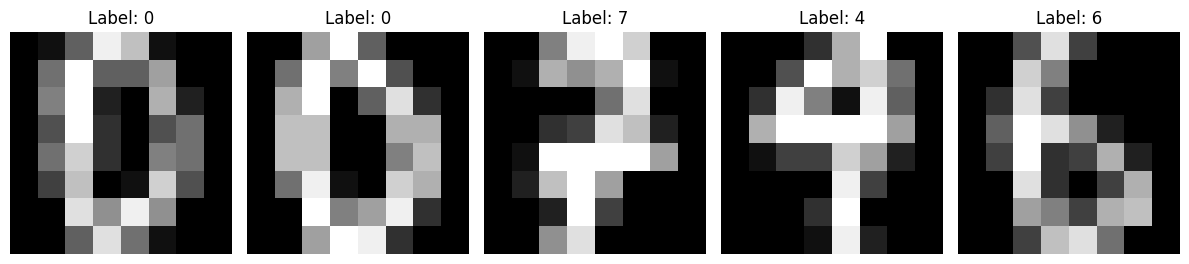

In [6]:
def image8x8_from_flat(flat64):
    img = []
    k = 0
    for _ in range(8):
        row = []
        for _ in range(8):
            row.append(flat64[k])
            k += 1
        img.append(row)
    return img

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, idx in enumerate(range(5)):
    features = X_train[idx]
    label = y_train[idx]
    
    image_2d = image8x8_from_flat(features)
    
    axes[i].imshow(image_2d, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Вспомогательные функции

In [7]:
NUM_FEATURES = 64
NUM_CLASSES = 10

def one_hot(labels, num_classes=10):
    out = []
    for y in labels:
        row = [0.0] * num_classes
        row[y] = 1.0
        out.append(row)
    return out

def batch_iter(X, y, batch_size, shuffle=True):
    idx = list(range(len(X)))
    if shuffle:
        random.shuffle(idx)

    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start:start + batch_size]
        xb = [X[i] for i in batch_idx]
        yb = [y[i] for i in batch_idx]
        yield xb, yb

def argmax(row):
    best_i = 0
    best_v = row[0]
    for i, v in enumerate(row):
        if v > best_v:
            best_v = v
            best_i = i
    return best_i

def accuracy_from_logits(logits_2d, labels):
    correct = 0
    for logit_row, y in zip(logits_2d, labels):
        pred = argmax(logit_row)
        if pred == y:
            correct += 1
    return correct / len(labels)

def xavier_uniform_values(rows, cols, rng):
    limit = math.sqrt(6.0 / (rows + cols))
    vals = []
    for _ in range(rows * cols):
        vals.append(rng.uniform(-limit, limit))
    return vals

# Демонстрация логистической регрессии

Попробуем такое вот реализовать
```txt
X [B x 64]
logits = X @ W + b
loss = softmax_cross_entropy(logits, y_onehot)
```

In [8]:
tg = TinyGradC(LIB_PATH)

W = tg.param(NUM_FEATURES, NUM_CLASSES, True)
b = tg.param(1, NUM_CLASSES, True)
params = [W, b]

rng = random.Random(42)
tg.copy_list_into_param(W, xavier_uniform_values(NUM_FEATURES, NUM_CLASSES, rng))
tg.copy_list_into_param(b, [0.0] * NUM_CLASSES)

print("Model initialized: Logistic regression 64 -> 10")

Model initialized: Logistic regression 64 -> 10


## Forward, predict и train_loop

In [9]:
def forward_logreg(tg, x_t, W, b):
    logits = tg.matmul(x_t, W)
    logits = tg.add(logits, b)
    return logits

def predict_logits_dataset(tg, X, batch_size=128):
    all_logits = []

    for xb, _ in batch_iter(X, [0] * len(X), batch_size, shuffle=False):
        x_t, x_buf = tg.tensor_from_2d_list(xb, requires_grad=False)
        logits_t = forward_logreg(tg, x_t, W, b)
        logits = tg.read_tensor_as_2d_list(logits_t, len(xb), NUM_CLASSES)
        all_logits.extend(logits)
        tg.reset()

    return all_logits

EPOCHS = 25
BATCH_SIZE = 64
LR = 1e-2

history_loss = []
history_train_acc = []
history_test_acc = []

step = 0

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    num_batches = 0

    for xb, yb_labels in batch_iter(X_train, y_train, BATCH_SIZE, shuffle=True):
        yb = one_hot(yb_labels, NUM_CLASSES)

        tg.zero_grads(params)

        x_t, x_buf = tg.tensor_from_2d_list(xb, requires_grad=False)
        y_t, y_buf = tg.tensor_from_2d_list(yb, requires_grad=False)

        logits_t = forward_logreg(tg, x_t, W, b)
        loss_t = tg.softmax_ce(logits_t, y_t)

        loss_value = tg.scalar(loss_t)
        tg.backward(loss_t)

        step += 1
        tg.adam_step(params, lr=LR, beta1=0.9, beta2=0.999, eps=1e-8, t=step)

        total_loss += loss_value
        num_batches += 1

        tg.reset()

    train_logits = predict_logits_dataset(tg, X_train, batch_size=256)
    test_logits = predict_logits_dataset(tg, X_test, batch_size=256)

    avg_loss = total_loss / max(1, num_batches)
    train_acc = accuracy_from_logits(train_logits, y_train)
    test_acc = accuracy_from_logits(test_logits, y_test)

    history_loss.append(avg_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    print(
        f"epoch={epoch:02d} "
        f"loss={avg_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"test_acc={test_acc:.4f}"
    )

epoch=01 loss=1.3152 train_acc=0.9050 test_acc=0.8893
epoch=02 loss=0.5216 train_acc=0.9349 test_acc=0.9165
epoch=03 loss=0.3488 train_acc=0.9472 test_acc=0.9249
epoch=04 loss=0.2746 train_acc=0.9537 test_acc=0.9304
epoch=05 loss=0.2324 train_acc=0.9592 test_acc=0.9338
epoch=06 loss=0.2060 train_acc=0.9602 test_acc=0.9354
epoch=07 loss=0.1858 train_acc=0.9642 test_acc=0.9338
epoch=08 loss=0.1698 train_acc=0.9663 test_acc=0.9388
epoch=09 loss=0.1585 train_acc=0.9660 test_acc=0.9377
epoch=10 loss=0.1499 train_acc=0.9681 test_acc=0.9399
epoch=11 loss=0.1406 train_acc=0.9686 test_acc=0.9393
epoch=12 loss=0.1336 train_acc=0.9694 test_acc=0.9421
epoch=13 loss=0.1290 train_acc=0.9720 test_acc=0.9405
epoch=14 loss=0.1228 train_acc=0.9731 test_acc=0.9421
epoch=15 loss=0.1177 train_acc=0.9738 test_acc=0.9449
epoch=16 loss=0.1134 train_acc=0.9728 test_acc=0.9455
epoch=17 loss=0.1114 train_acc=0.9752 test_acc=0.9432
epoch=18 loss=0.1065 train_acc=0.9772 test_acc=0.9460
epoch=19 loss=0.1029 train_a

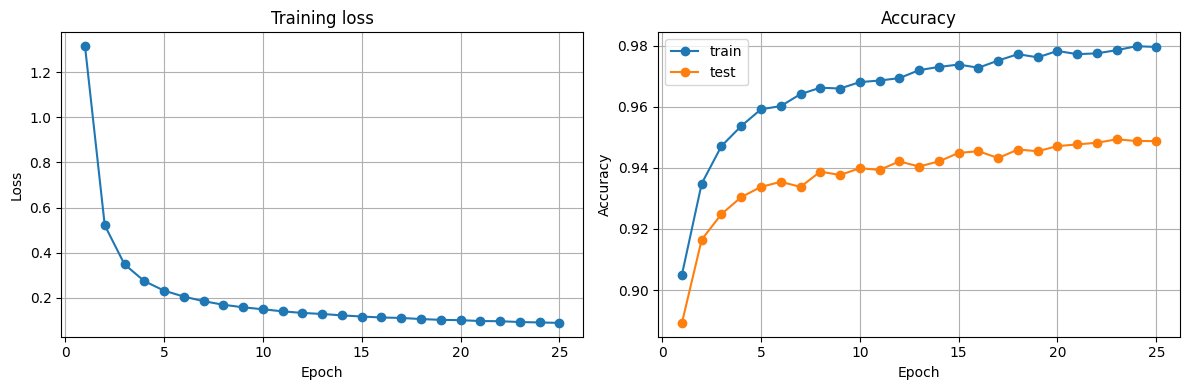

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(history_loss) + 1), history_loss, marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(range(1, len(history_train_acc) + 1), history_train_acc, marker="o", label="train")
axes[1].plot(range(1, len(history_test_acc) + 1), history_test_acc, marker="o", label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Смотрим предсказания

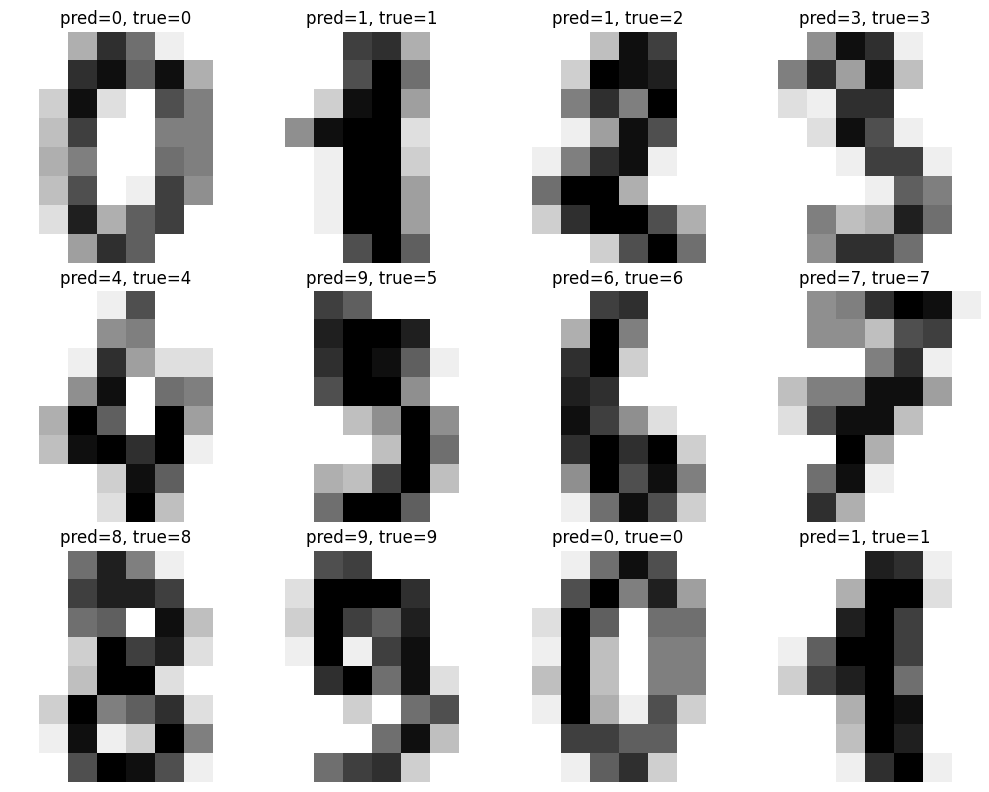

In [11]:
sample_count = 12
sample_logits = predict_logits_dataset(tg, X_test[:sample_count], batch_size=sample_count)
sample_preds = [argmax(row) for row in sample_logits]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    img = image8x8_from_flat(X_test[i])
    true_label = y_test[i]
    pred_label = sample_preds[i]

    ax.imshow(img, cmap="gray_r", vmin=0.0, vmax=1.0)
    ax.set_title(f"pred={pred_label}, true={true_label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Визуализация весов классов

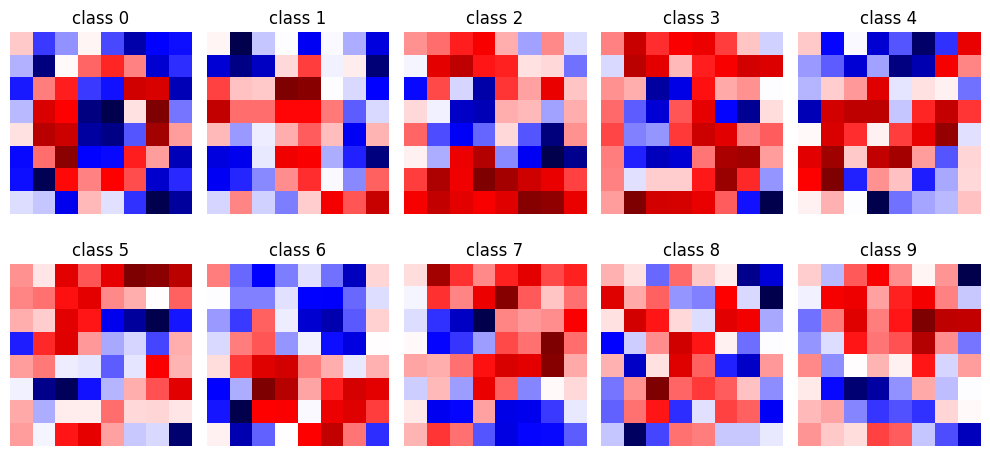

In [12]:
W_values = tg.read_tensor_as_2d_list(W, NUM_FEATURES, NUM_CLASSES)

class_maps = []
for cls in range(NUM_CLASSES):
    flat = []
    for feat in range(NUM_FEATURES):
        flat.append(W_values[feat][cls])
    class_maps.append(image8x8_from_flat(flat))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for cls, ax in enumerate(axes.flat):
    ax.imshow(class_maps[cls], cmap="seismic")
    ax.set_title(f"class {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Явное освобождение ресурсов
tg.free_param(W)
tg.free_param(b)
tg.close()
print("Done")

Done
